# Регрессия для CC50

Цель — предсказать численное значение `CC50, mM` по химическим дескрипторам соединений.

Сравниваются несколько моделей: наивный baseline, Ridge, SVR, RandomForest и GradientBoosting. Для лучшей модели градиентного бустинга выполняется компактный подбор гиперпараметров.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC

RANDOM_STATE = 42
TARGET_COLUMNS = ['IC50, mM', 'CC50, mM', 'SI']
DATA_PATH = Path('../data/drug_activity.csv')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)


def load_data():
    df = pd.read_csv(DATA_PATH)
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    return df


def split_features_target(df, target):
    # Важно: удаляем все три целевые колонки, чтобы не было утечки данных.
    # SI рассчитывается через IC50 и CC50, поэтому их нельзя использовать как признаки.
    X = df.drop(columns=[c for c in TARGET_COLUMNS if c in df.columns])
    y = df[target]
    return X, y


def make_binary_target(y, mode):
    if mode == 'median':
        threshold = y.median()
    elif mode == 'si_gt_8':
        threshold = 8.0
    else:
        raise ValueError(mode)
    return (y > threshold).astype(int), threshold


def preprocessing_steps(scale=False):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold())
    ]
    if scale:
        steps.append(('scaler', StandardScaler()))
    return steps


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


def classification_metrics(y_true, y_pred, y_proba=None):
    res = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        res['ROC_AUC'] = roc_auc_score(y_true, y_proba)
    return res


def regression_models():
    return {
        'DummyMean': Pipeline(preprocessing_steps(False) + [
            ('model', DummyRegressor(strategy='mean'))
        ]),
        'Ridge_log_y': TransformedTargetRegressor(
            regressor=Pipeline(preprocessing_steps(True) + [
                ('model', Ridge(alpha=10.0))
            ]),
            func=np.log1p,
            inverse_func=np.expm1
        ),
        'SVR_RBF_log_y': TransformedTargetRegressor(
            regressor=Pipeline(preprocessing_steps(True) + [
                ('model', SVR(C=5.0, epsilon=0.1, gamma='scale'))
            ]),
            func=np.log1p,
            inverse_func=np.expm1
        ),
        'RandomForest': Pipeline(preprocessing_steps(False) + [
            ('model', RandomForestRegressor(
                n_estimators=120,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        'GradientBoosting': Pipeline(preprocessing_steps(False) + [
            ('model', GradientBoostingRegressor(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=2,
                random_state=RANDOM_STATE
            ))
        ]),
    }


def tune_gradient_boosting_regression(X_train, y_train, X_valid, y_valid):
    # Компактный ручной подбор гиперпараметров: быстро работает на ноутбуке.
    params = [
        {'n_estimators': 60, 'learning_rate': 0.05, 'max_depth': 2},
        {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},
        {'n_estimators': 80, 'learning_rate': 0.08, 'max_depth': 2},
        {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3},
    ]
    rows = []
    best_model = None
    best_rmse = np.inf
    for p in params:
        model = Pipeline(preprocessing_steps(False) + [
            ('model', GradientBoostingRegressor(random_state=RANDOM_STATE, **p))
        ])
        model.fit(X_train, y_train)
        pred = np.maximum(model.predict(X_valid), 0)
        metrics = regression_metrics(y_valid, pred)
        row = {**p, **metrics}
        rows.append(row)
        if metrics['RMSE'] < best_rmse:
            best_rmse = metrics['RMSE']
            best_model = model
    return best_model, pd.DataFrame(rows).sort_values('RMSE')


In [2]:
df = load_data()
X, y = split_features_target(df, 'CC50, mM')
print('Размер X:', X.shape)
print('Целевая переменная:', 'CC50, mM')

display(y.describe())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Размер X: (1001, 210)
Целевая переменная: CC50, mM


count    1001.000000
mean      589.110728
std       642.867508
min         0.700808
25%        99.999036
50%       411.039342
75%       894.089177
max      4538.976189
Name: CC50, mM, dtype: float64

Train: (800, 210) Test: (201, 210)


## Сравнение базовых моделей


In [3]:
rows = []
for name, model in regression_models().items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_test), 0)
    row = {'model': name}
    row.update(regression_metrics(y_test, pred))
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values('RMSE')
display(metrics_df)


,model,MAE,RMSE,R2
3,RandomForest,285.253843,457.364363,0.596524
4,GradientBoosting,311.316724,475.994492,0.562985
2,SVR_RBF_log_y,294.410024,496.775750,0.523993
1,Ridge_log_y,368.062176,593.246660,0.321166
0,DummyMean,511.729334,723.054208,-0.008404


## Подбор гиперпараметров GradientBoostingRegressor


In [4]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE
)

best_tuned_model, tuning_df = tune_gradient_boosting_regression(
    X_fit, y_fit, X_valid, y_valid
)

display(tuning_df)


,n_estimators,learning_rate,max_depth,MAE,RMSE,R2
3,100,0.05,3,296.455446,391.909551,0.462953
2,80,0.08,2,311.467060,399.707322,0.441370
1,100,0.05,2,324.828675,410.047441,0.412093
0,60,0.05,2,350.348726,433.583525,0.342666


## Финальное сравнение с настроенным бустингом


In [5]:
best_tuned_model.fit(X_train, y_train)
pred = np.maximum(best_tuned_model.predict(X_test), 0)

tuned_row = {'model': 'Tuned_GradientBoosting'}
tuned_row.update(regression_metrics(y_test, pred))

final_metrics = pd.concat([
    metrics_df,
    pd.DataFrame([tuned_row])
], ignore_index=True).sort_values('RMSE')

display(final_metrics)

final_metrics.to_csv(RESULTS_DIR / 'regression_cc50_metrics.csv', index=False)
tuning_df.to_csv(RESULTS_DIR / 'regression_cc50_tuning.csv', index=False)


,model,MAE,RMSE,R2
0,RandomForest,285.253843,457.364363,0.596524
5,Tuned_GradientBoosting,304.081862,466.790096,0.579722
1,GradientBoosting,311.316724,475.994492,0.562985
2,SVR_RBF_log_y,294.410024,496.775750,0.523993
3,Ridge_log_y,368.062176,593.246660,0.321166
4,DummyMean,511.729334,723.054208,-0.008404


## Визуализация ошибок лучшей модели


Лучшая модель по RMSE: RandomForest


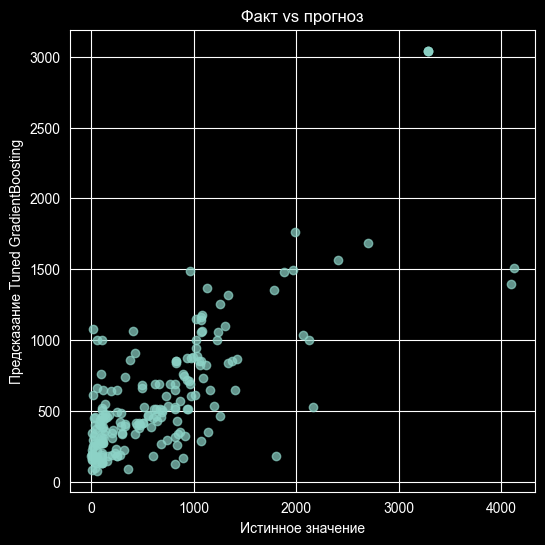

In [6]:
best_name = final_metrics.iloc[0]['model']
print('Лучшая модель по RMSE:', best_name)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.7)
plt.xlabel('Истинное значение')
plt.ylabel('Предсказание Tuned GradientBoosting')
plt.title('Факт vs прогноз')
plt.grid(True)
plt.show()


## Вывод по регрессии CC50

В задаче сравниваются линейные, SVM- и ансамблевые модели. Лучшая модель выбирается по минимальному RMSE. Для повышения качества можно расширить сетку гиперпараметров, использовать более строгую кросс-валидацию и дополнительно исследовать выбросы в целевой переменной.
